# (노트) DataLoaders, Leaner

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

### Dataset - pytorch

In [1]:
import torch
from fastai.vision.all import *

In [2]:
X=torch.tensor([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
y=torch.tensor([1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0])

In [3]:
ds=torch.utils.data.TensorDataset(X,y) # 그냥 텐서들의 pair

In [4]:
ds

In [5]:
dir(ds)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_is_protocol',
 'tensors']

In [6]:
ds.tensors # 그냥 텐서들의 pair

(tensor([3., 4., 5., 6., 7., 8., 9.]), tensor([1., 0., 1., 1., 1., 0., 1.]))

### DataLoader - pytorch, fastai 

#### pytorch

`-` 셔플 True

In [7]:
dl=torch.utils.data.DataLoader(ds,batch_size=2,shuffle=True)

In [8]:
dl

In [9]:
dir(dl)

['_DataLoader__initialized',
 '_DataLoader__multiprocessing_context',
 '_IterableDataset_len_called',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_auto_collation',
 '_dataset_kind',
 '_get_iterator',
 '_index_sampler',
 '_is_protocol',
 '_iterator',
 'batch_sampler',
 'batch_size',
 'check_worker_number_rationality',
 'collate_fn',
 'dataset',
 'drop_last',
 'generator',
 'multiprocessing_context',
 'num_workers',
 'persistent_workers',
 'pin_memory',
 'prefetch_factor',
 'sampler',
 'timeout',
 'worker_init_fn']

- 배치만드는 기능들이 있어보임 

In [10]:
for xx,yy in dl: 
    print(xx,yy)

tensor([4., 6.]) tensor([0., 1.])
tensor([3., 7.]) tensor([1., 1.])
tensor([9., 5.]) tensor([1., 1.])
tensor([8.]) tensor([0.])


- 실행할때마다 위의 결과는 바뀜

`-` 셔플 False

In [11]:
dl=torch.utils.data.DataLoader(ds,batch_size=2,shuffle=False)

In [12]:
for xx,yy in dl: 
    print(xx,yy)

tensor([3., 4.]) tensor([1., 0.])
tensor([5., 6.]) tensor([1., 1.])
tensor([7., 8.]) tensor([1., 0.])
tensor([9.]) tensor([1.])


- 실행해도 위의 결과는 동일 

`-` batch_size=3

In [13]:
dl=torch.utils.data.DataLoader(ds,batch_size=3,shuffle=True)

In [14]:
dl

In [15]:
for xx,yy in dl: 
    print(xx,yy)

tensor([9., 4., 7.]) tensor([1., 0., 1.])
tensor([6., 8., 3.]) tensor([1., 0., 1.])
tensor([5.]) tensor([1.])


#### fastai

In [16]:
dl2=DataLoader(ds,batch_size=3,shuffle=True)

In [17]:
dl2

In [18]:
dir(dl2)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__stored_args__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_component_attr_filter',
 '_default',
 '_dir',
 '_is_protocol',
 '_methods',
 '_noop_methods',
 'after_batch',
 'after_item',
 'after_iter',
 'before_batch',
 'before_iter',
 'bs',
 'chunkify',
 'create_batch',
 'create_batches',
 'create_item',
 'dataset',
 'device',
 'do_batch',
 'do_item',
 'drop_last',
 'fake_l',
 'get_idxs',
 'indexed',
 'n',
 'new',
 'num_workers',
 'o',
 'offs',
 'one_batch',
 'pin_memory',
 'prebatched',
 'randomize',
 'retain',
 'rng',
 'sample',
 'shuffle',
 'shuffle_fn',
 'tensors',
 'timeout',
 'to',
 'wif']

- 뭔가 기능들이 더 추가된 듯

In [19]:
for xx,yy in dl2: 
    print(xx,yy)

tensor([8., 7., 3.]) tensor([0., 1., 1.])
tensor([6., 9., 4.]) tensor([1., 1., 0.])
tensor([5.]) tensor([1.])


- 일단 결과는 동일함 

### Dataloaders - fastai

In [20]:
from fastai.vision.all import *

In [21]:
dls=DataLoaders(dl)
dls2=DataLoaders(dl2)

- dl로도, dl2로도 데이터로더스를 만들 수 있다. 

### MNIST 3/7 예제 

`-` 우선 텐서로 이루어진 X,y를 만들자. 

In [22]:
path = untar_data(URLs.MNIST_SAMPLE)

In [23]:
threes=(path/'train'/'3').ls()
sevens=(path/'train'/'7').ls()

In [24]:
seven_tensor = torch.stack([tensor(Image.open(i)) for i in sevens]).float()/255
three_tensor = torch.stack([tensor(Image.open(i)) for i in threes]).float()/255

In [25]:
X=torch.vstack([seven_tensor,three_tensor]).reshape(12396,-1)
y=torch.tensor([0.0]*6265 + [1.0]*6131).reshape(12396,1)

In [26]:
X.shape, y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

`-` dataset=(X,y) 를 만들자 

In [27]:
ds=torch.utils.data.TensorDataset(X,y)

`-` dataloader를 만들자.

In [28]:
dl1=torch.utils.data.DataLoader(ds,batch_size=2048)
dl2=DataLoader(ds,batch_size=2048)

`-` 네트워크(아키텍처), 손실함수, 옵티마이저 

In [29]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(28*28,30),
    torch.nn.ReLU(),
    torch.nn.Linear(30,1)
    #torch.nn.Sigmoid()
)
loss_fn=torch.nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(net.parameters())

`-` 저번시간 복습

In [30]:
for epoc in range(200): 
    ## 1 
    yhat=net(X) 
    ## 2 
    loss= loss_fn(yhat,y) ## BCEloss
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step() 
    net.zero_grad()

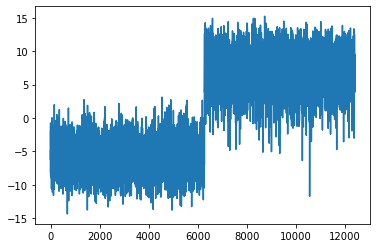

In [31]:
plt.plot(yhat.data)

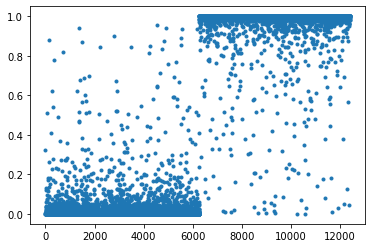

In [32]:
f=torch.nn.Sigmoid()
plt.plot(f(yhat.data),'.')

`-` 미니배치활용 

In [33]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(28*28,30),
    torch.nn.ReLU(),
    torch.nn.Linear(30,1),
    #torch.nn.Sigmoid()
)
loss_fn=torch.nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(net.parameters())

- 네트워크 파라페터 다시 초기화 

In [34]:
12396/2048 # 12396 = number of observation & 2048 = batch size (number of observation in batch)

6.052734375

- 총 7개의 미니배치가 만들어질것임 $\to$ 따라서 파라메터를 업데이트하는 횟수는 7*epoc 임 (실질적으로는 6 * epoc) 

In [35]:
200/6

33.333333333333336

In [36]:
for epoc in range(33): 
    for xx,yy in dl1:
        ## 1 
        yyhat=net(xx) 
        ## 2 
        loss= loss_fn(yyhat,yy) ## BCElos
        ## 3 
        loss.backward()
        ## 4 
        optimizer.step() 
        net.zero_grad()

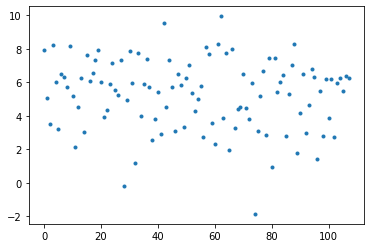

In [37]:
plt.plot(yyhat.data,'.')

- ?? 이거 왜이러지? 

`-` 배치사이즈를 확인해보자. 

In [38]:
for xx,yy in dl1:
    print(xx.shape,yy.shape)

torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([108, 784]) torch.Size([108, 1])


`-` 마지막이 108개이므로 108개의 y만 그려진것임. 

`-` $n=12396$개를 그리고 싶다면 아래와 같이 그리면 된다. 

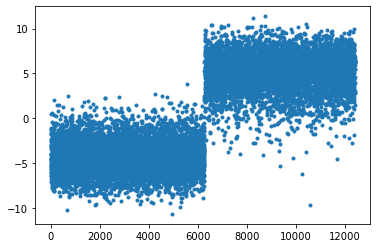

In [39]:
plt.plot(net(X).data,'.')

`-` 2048개 정도만 대충학습해도 동일 반복횟수에 대하여 거의 대등한 효율이 나옴 

`-` GPU로 12396개의 자료를 모두 보내지 않아도 괜찮겠다. $\to$ 그래픽카드의 메모리를 얼마나 큰것으로 살지는 자료의 크기와 관계없다. 

`-` 그렇지만 net.parameters()는 그대로 보내야함. (이건 어쩔수 없음) $\to$ 그래픽카드의 메모리를 얼마나 큰것으로 살지는 모형의 복잡도와 관련있다. 

***컴퓨터고르는방법요약*** 
- 메모리: $n$이 큰 자료를 다룰수록 메모리가 커야한다. 
- GPU의 메모리: 모형의 복잡도가 커질수록 GPU의 메모리가 커져야한다. 

### Learner를 이용 

`-` 생각해보니까 슬슬 for문이 복잡해지는것 같다. 

`-` 그리고 반복하는 루틴은 어차피 동일한것 같다. 

In [128]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(28*28,30),
    torch.nn.ReLU(),
    torch.nn.Linear(30,1),
    #torch.nn.Sigmoid()
)

In [129]:
dls=DataLoaders(dl1,dl1) ## 약간트릭이에요~ 

In [130]:
lrnr = Learner(dls,net,opt_func=Adam,loss_func=BCEWithLogitsLossFlat()) 

In [131]:
lrnr.fit(33) ## 알아서 GPU를 잘쓰면서 학습한다. 

epoch,train_loss,valid_loss,time
0,0.775811,0.665016,00:00
1,0.701643,0.601382,00:00
2,0.653838,0.538519,00:00
3,0.610215,0.462972,00:00
4,0.565773,0.390488,00:00
5,0.520116,0.324925,00:00
6,0.473669,0.269587,00:00
7,0.429447,0.229561,00:00
8,0.389544,0.198800,00:00
9,0.353915,0.174334,00:00


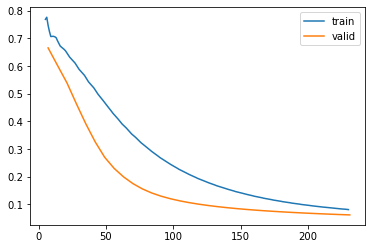

In [135]:
lrnr.recorder.plot_loss()